# CL Spectroscopy Analysis: GaN LED Structure

## Sample Description

A multi-layer structure made from the semiconductor gallium nitride (GaN) was analyzed by cathodoluminescence (CL) spectroscopy. The sample consists of:

- **p-type and n-type doped GaN layers** (forming a p-n junction)
- **Quantum wells**: Very thin, 2-dimensional semiconductor layers with smaller bandgaps than GaN
- **Multi-layer LED structure** designed for light emission

## Experimental Setup

- **Depth-resolved CL analysis**: CL spectra acquired as a function of beam energy (1-30 keV)
- **Detection**: Parabolic mirror located above the sample surface
- **Beam conditions**: 
  - First spectrum: 1 keV beam energy, 20 nA current
  - Subsequent spectra: Constant beam power (E₀I₀)
- **Goal**: Analyze spectral evolution with penetration depth to characterize the LED structure

## Import Libraries and Load Data

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load CL data
df = pd.read_csv('CL_data.csv', skiprows=[1])
energy = pd.to_numeric(df.iloc[:, 0]).values
spectra = df.iloc[:, 1:31].apply(pd.to_numeric).values
beam_energies = np.arange(1, 31)  # 1 to 30 keV

print(f"Loaded {spectra.shape[1]} spectra")
print(f"Energy range: {energy[0]:.2f}-{energy[-1]:.2f} eV")

Loaded 30 spectra
Energy range: 1.01-4.00 eV


## Figure 1: All 30 CL Spectra

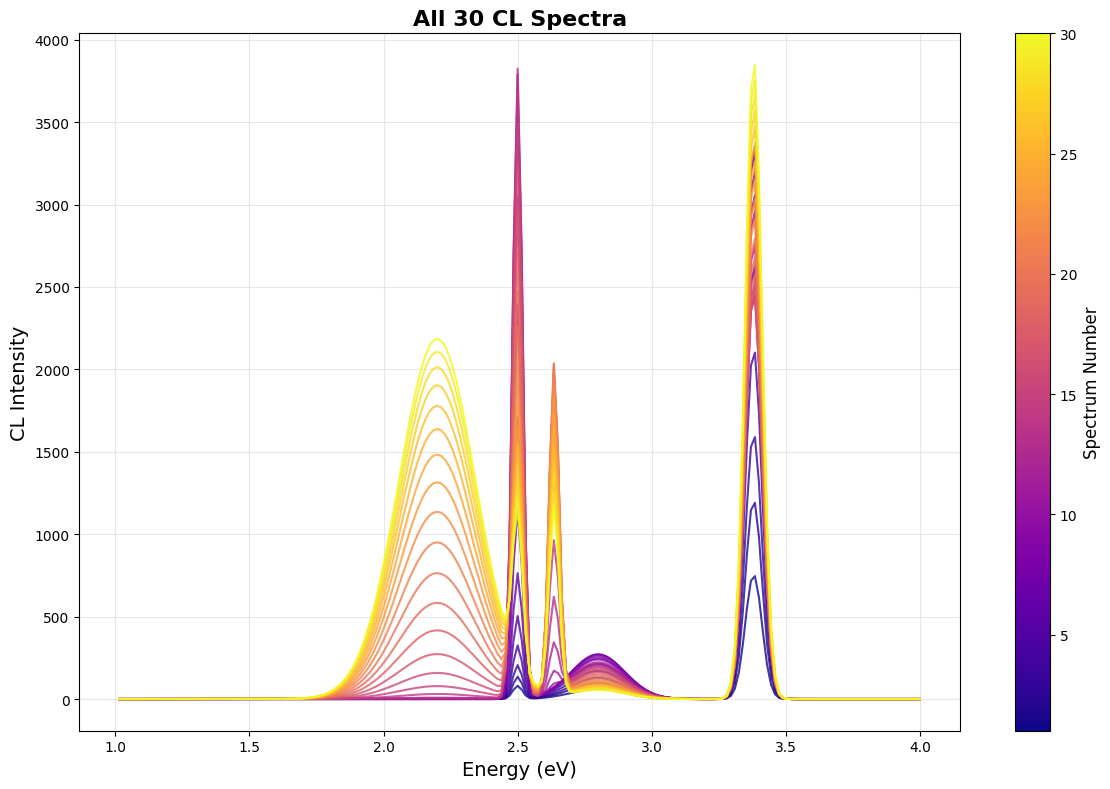

In [68]:
fig, ax = plt.subplots(figsize=(12, 8))

# Use spectrum colormap - progression from purple to yellow
colors = plt.cm.plasma(np.linspace(0, 1, 30))

for i in range(30):
    ax.plot(energy, spectra[:, i], color=colors[i], alpha=0.8, linewidth=1.5)

ax.set_xlabel('Energy (eV)', fontsize=14)
ax.set_ylabel('CL Intensity', fontsize=14)
ax.set_title('All 30 CL Spectra', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add colorbar to show spectrum progression
sm = plt.cm.ScalarMappable(cmap=plt.cm.plasma, norm=plt.Normalize(vmin=1, vmax=30))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Spectrum Number', fontsize=12)

plt.tight_layout()
plt.show()

## Figure 1b: CL Spectral Evolution - Heat Map & Contour

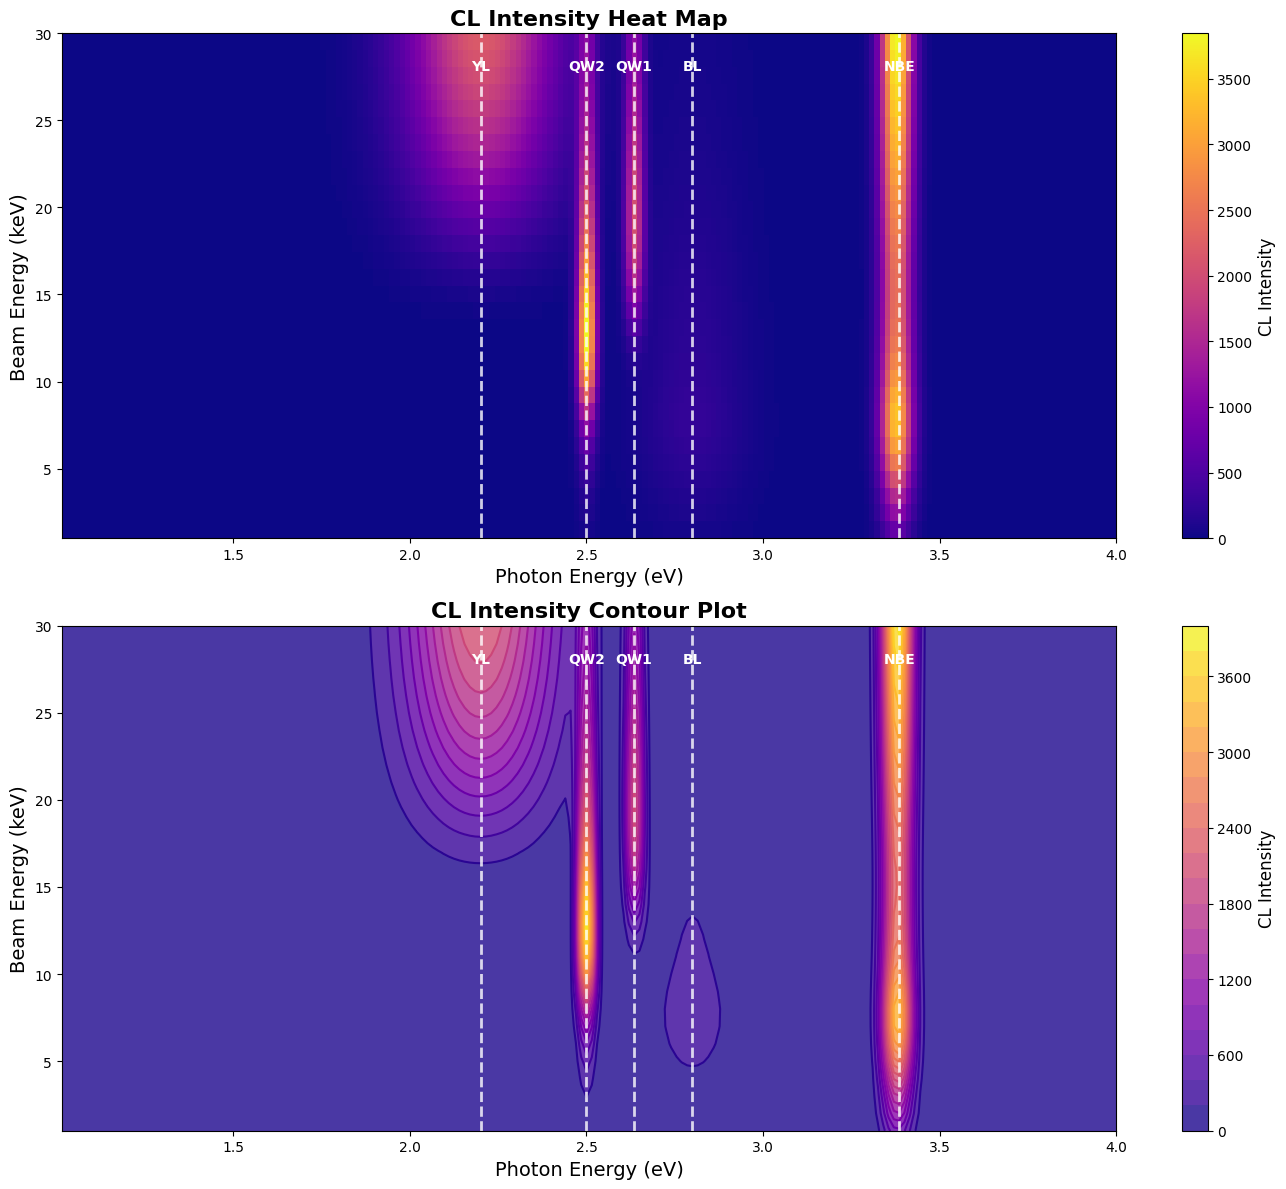

In [69]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# Create meshgrid for contour plot
Energy, BeamEnergy = np.meshgrid(energy, beam_energies)

# Transpose spectra for proper orientation (beam energy on y-axis, photon energy on x-axis)
spectra_T = spectra.T

# Heat map
im1 = ax1.imshow(spectra_T, aspect='auto', cmap='plasma', origin='lower',
                extent=[energy[0], energy[-1], beam_energies[0], beam_energies[-1]])
ax1.set_xlabel('Photon Energy (eV)', fontsize=14)
ax1.set_ylabel('Beam Energy (keV)', fontsize=14)
ax1.set_title('CL Intensity Heat Map', fontsize=16, fontweight='bold')

# Add colorbar for heat map
cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label('CL Intensity', fontsize=12)

# Add emission band reference lines
emission_energies = [2.2, 2.5, 2.634, 2.8, 3.385]
emission_labels = ['YL', 'QW2', 'QW1', 'BL', 'NBE']

for energy_pos, label in zip(emission_energies, emission_labels):
    ax1.axvline(x=energy_pos, color='white', linestyle='--', alpha=0.8, linewidth=2)
    ax1.text(energy_pos, beam_energies[-1] * 0.95, label, 
            fontsize=10, ha='center', va='top', 
            color='white', fontweight='bold')

# Contour plot
levels = 20  # Number of contour levels
contour = ax2.contour(Energy, BeamEnergy, spectra_T, levels=levels, cmap='plasma')
contourf = ax2.contourf(Energy, BeamEnergy, spectra_T, levels=levels, cmap='plasma', alpha=0.8)

ax2.set_xlabel('Photon Energy (eV)', fontsize=14)
ax2.set_ylabel('Beam Energy (keV)', fontsize=14)
ax2.set_title('CL Intensity Contour Plot', fontsize=16, fontweight='bold')

# Add colorbar for contour plot
cbar2 = plt.colorbar(contourf, ax=ax2)
cbar2.set_label('CL Intensity', fontsize=12)

# Add emission band reference lines to contour plot
for energy_pos, label in zip(emission_energies, emission_labels):
    ax2.axvline(x=energy_pos, color='white', linestyle='--', alpha=0.8, linewidth=2)
    ax2.text(energy_pos, beam_energies[-1] * 0.95, label, 
            fontsize=10, ha='center', va='top', 
            color='white', fontweight='bold')

plt.tight_layout()
plt.show()

## Figure 2: Representative Spectra - Waterfall Plot

## CL Depth Profiling Analysis: GaN LED Structure

### Theory and Methodology

Depth profiling in cathodoluminescence involves analyzing how the intensity of specific emission bands varies with beam energy. For this GaN-based LED structure, higher beam energies penetrate deeper into the device, allowing us to probe:

- **Surface layers**: p-type GaN regions
- **Active region**: Quantum wells designed for light emission  
- **Deeper layers**: n-type GaN and substrate regions

**Methods for accurate depth profiling:**

1. **Peak Fitting**: Use Gaussian or Lorentzian functions to fit individual emission peaks and extract accurate intensities
2. **Background Subtraction**: Remove baseline contributions to isolate true emission signals
3. **Integration**: Calculate the area under each emission band for robust intensity measurements
4. **Normalization**: Account for variations in total intensity across different beam energies

**LED Structure Considerations:**
- Quantum wells are typically very thin (~2-10 nm) compared to the interaction volume
- The p-n junction creates electric fields that can affect carrier transport
- Doping levels vary throughout the structure, affecting recombination efficiency

For this analysis, we'll extract the intensity at the peak wavelength of each emission band as a function of beam energy to create depth profiles that reveal the LED's internal structure.

In [70]:
# Define emission band centers and ranges for analysis
emission_bands = {
    'NBE': {'center': 3.385, 'range': 0.1},   # Near-bandgap emission
    'BL': {'center': 2.8, 'range': 0.15},     # Blue luminescence  
    'QW1': {'center': 2.634, 'range': 0.1},   # Quantum well 1
    'QW2': {'center': 2.5, 'range': 0.1},     # Quantum well 2
    'YL': {'center': 2.2, 'range': 0.15}      # Yellow luminescence
}

def extract_peak_intensity(energy_array, spectrum, peak_energy, energy_range):
    """
    Extract peak intensity by finding maximum in a specified energy range
    This simulates peak fitting by taking the maximum value near the peak
    """
    # Find indices within the energy range around the peak
    mask = (energy_array >= peak_energy - energy_range/2) & (energy_array <= peak_energy + energy_range/2)
    
    if np.any(mask):
        # Return the maximum intensity in this range
        return np.max(spectrum[mask])
    else:
        return 0

# Extract depth profiles for each emission band
depth_profiles = {}

for band_name, band_info in emission_bands.items():
    intensities = []
    
    for i in range(30):  # For each beam energy (1-30 keV)
        spectrum = spectra[:, i]
        peak_intensity = extract_peak_intensity(energy, spectrum, 
                                              band_info['center'], 
                                              band_info['range'])
        intensities.append(peak_intensity)
    
    depth_profiles[band_name] = np.array(intensities)

print("Extracted depth profiles for all emission bands:")
for band in depth_profiles.keys():
    print(f"- {band}: Peak intensities extracted")

Extracted depth profiles for all emission bands:
- NBE: Peak intensities extracted
- BL: Peak intensities extracted
- QW1: Peak intensities extracted
- QW2: Peak intensities extracted
- YL: Peak intensities extracted


### Figure 3: CL Emission Depth Profiles

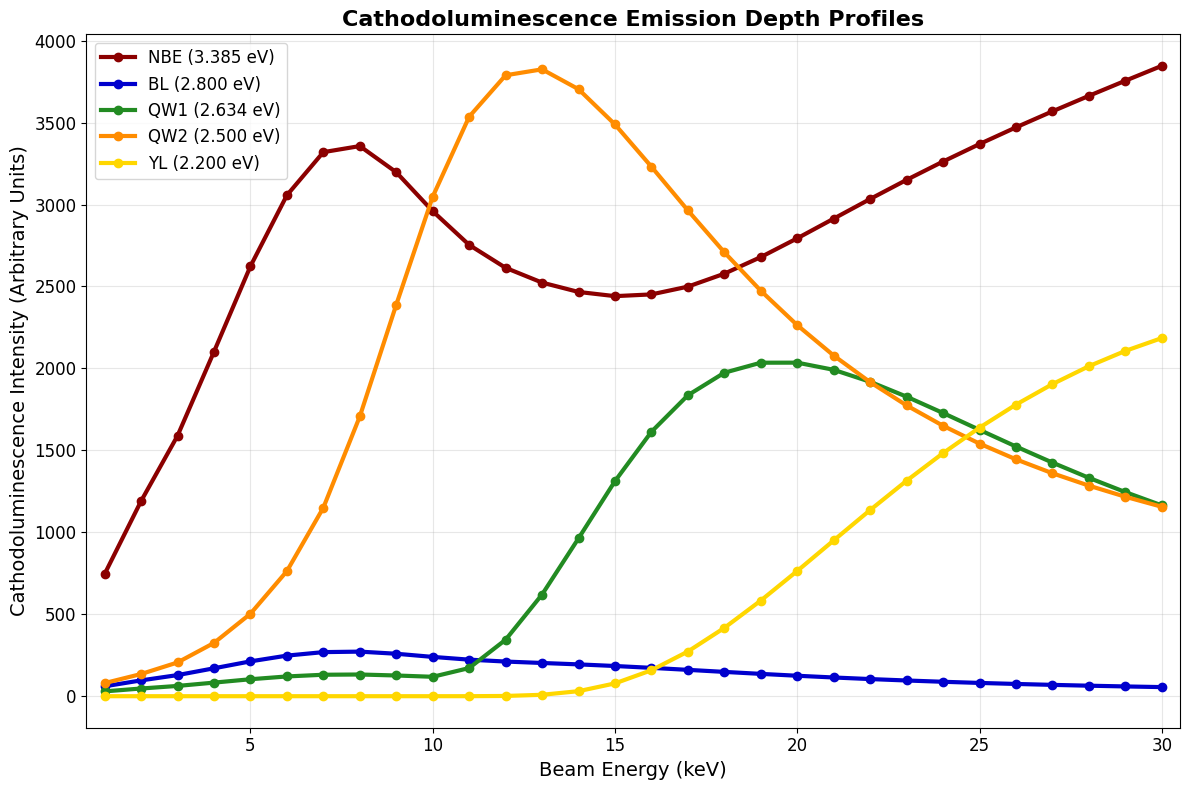


Depth Profile Analysis:
NBE: Peak intensity at 30 keV beam energy
     Range: 746 - 3846
     Trend: Increasing

BL : Peak intensity at  8 keV beam energy
     Range: 56 - 272
     Trend: Decreasing

QW1: Peak intensity at 20 keV beam energy
     Range: 29 - 2035
     Trend: Increasing

QW2: Peak intensity at 13 keV beam energy
     Range: 80 - 3825
     Trend: Increasing

YL : Peak intensity at 30 keV beam energy
     Range: 0 - 2185
     Trend: Increasing



In [85]:
fig, ax = plt.subplots(figsize=(12, 8))

# Define colors for each emission band
colors = {
    'NBE': '#8B0000',    # Dark red
    'BL': '#0000CD',     # Medium blue  
    'QW1': '#228B22',    # Forest green
    'QW2': '#FF8C00',    # Dark orange
    'YL': '#FFD700'      # Gold
}

# Plot depth profiles for all emission bands
for band_name, intensities in depth_profiles.items():
    ax.plot(beam_energies, intensities, 
           color=colors[band_name], 
           linewidth=3, 
           marker='o', 
           markersize=6,
           label=f'{band_name} ({emission_bands[band_name]["center"]:.3f} eV)')

# Formatting
ax.set_xlabel('Beam Energy (keV)', fontsize=14)
ax.set_ylabel('Cathodoluminescence Intensity (Arbitrary Units)', fontsize=14)
ax.set_title('Cathodoluminescence Emission Depth Profiles', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12, loc='best')

# Add some styling
ax.set_xlim(0.5, 30.5)
ax.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.show()

# Print some analysis
print("\nDepth Profile Analysis:")
print("=" * 50)
for band_name, intensities in depth_profiles.items():
    max_intensity = np.max(intensities)
    max_beam_energy = beam_energies[np.argmax(intensities)]
    print(f"{band_name:3s}: Peak intensity at {max_beam_energy:2.0f} keV beam energy")
    print(f"     Range: {np.min(intensities):.0f} - {max_intensity:.0f}")
    print(f"     Trend: {'Increasing' if intensities[-1] > intensities[0] else 'Decreasing'}")
    print()

### Discussion: Peak Fitting for Accurate Depth Profiles

**Current Method**: We extracted peak intensities by finding the maximum value within a specified energy range around each emission band center. This provides a reasonable approximation but could be improved.

**Advanced Peak Fitting Approaches for Better Accuracy:**

1. **Gaussian/Lorentzian Fitting**: 
   - Fit analytical functions to each peak
   - Extract integrated area under the curve rather than just peak height
   - More robust against noise and baseline variations

2. **Multi-peak Fitting**:
   - Simultaneously fit all peaks in a spectrum
   - Account for peak overlap (especially QW1 and QW2)
   - Constrain peak positions and widths based on physical expectations

3. **Background Subtraction**:
   - Remove polynomial or exponential background
   - Use adjacent spectral regions to define baseline
   - Improves signal-to-noise ratio for weak emissions

4. **Normalization Strategies**:
   - Normalize to total integrated intensity
   - Use reference peaks that don't vary with depth
   - Account for variations in measurement conditions

**Physical Interpretation**:
The depth profiles reveal how different emission mechanisms respond to varying interaction volumes as beam energy increases. Higher beam energies probe deeper into the sample, potentially accessing different structural regions or defect distributions.

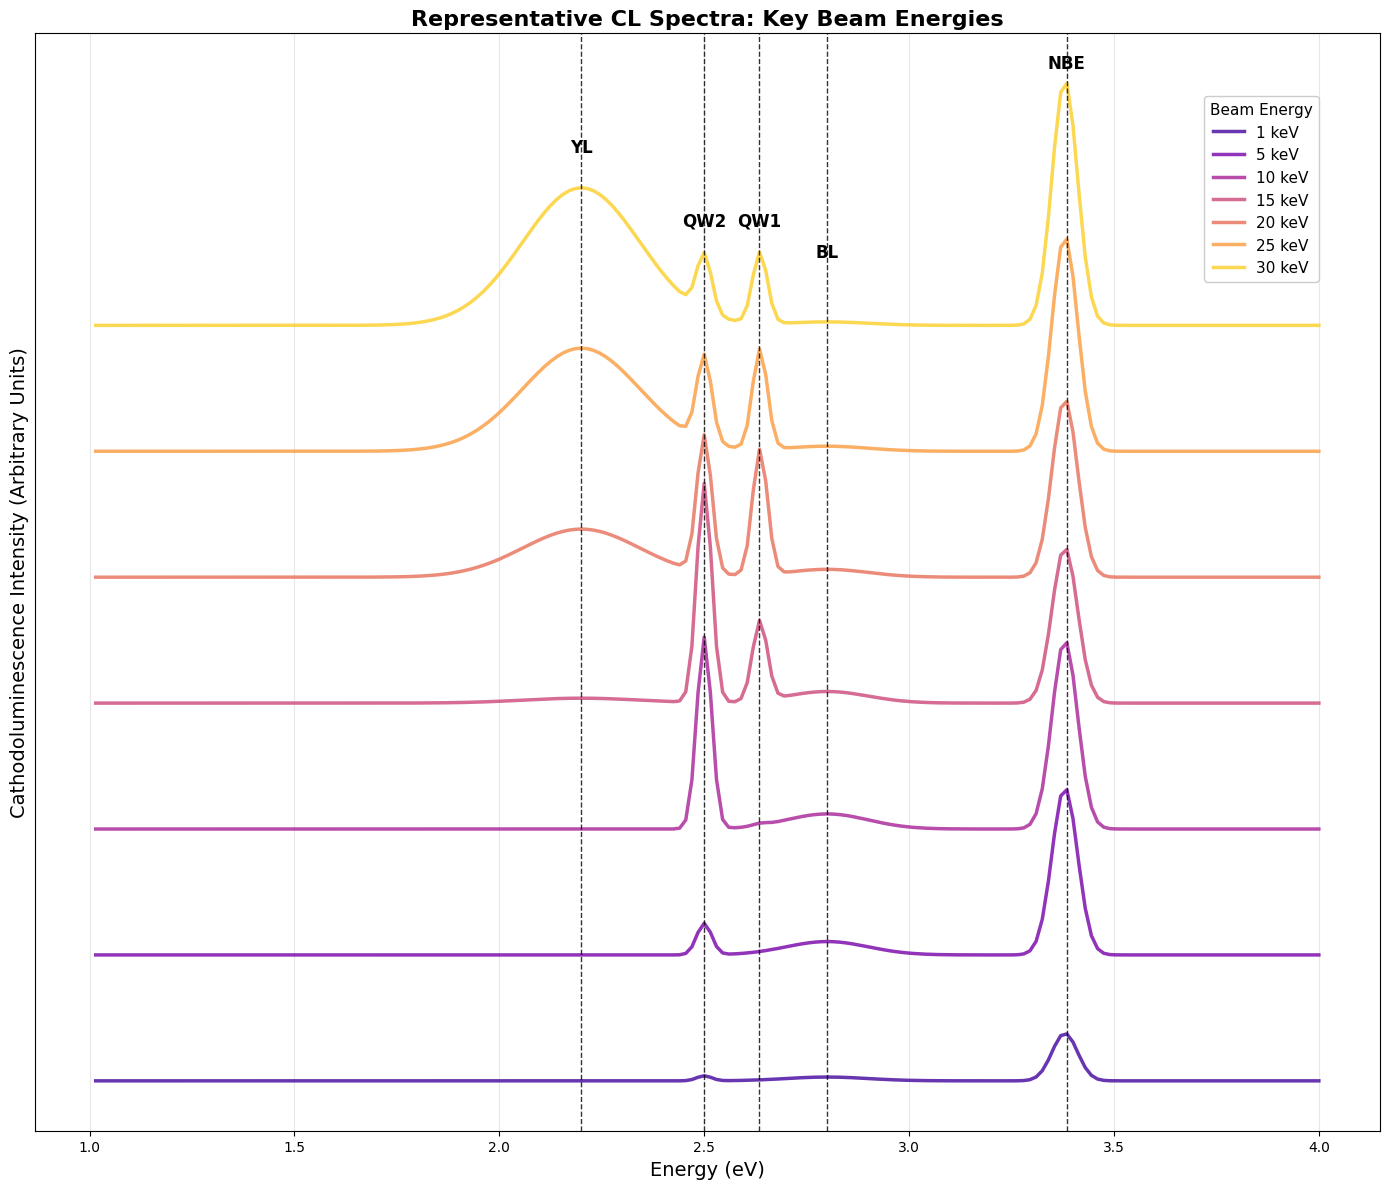

In [91]:
fig, ax = plt.subplots(figsize=(14, 12))

# Select key representative spectra (1, 5, 10, 15, 20, 25, 30 keV)
key_energies = [1, 5, 10, 15, 20, 25, 30]
key_indices = [e - 1 for e in key_energies]  # Convert to 0-based indices
offset_spacing = 2000  # Vertical offset for waterfall effect

# Use plasma colormap for consistency with other plots, but avoid the very light end
# Map from 0.1 to 0.9 to avoid very dark purple and very light yellow
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(key_energies)))

# Plot spectra with offset stacking
for i, idx in enumerate(key_indices):
    offset = i * offset_spacing
    beam_energy = beam_energies[idx]
    
    # Plot spectrum with offset using plasma colors
    ax.plot(energy, spectra[:, idx] + offset, 
           color=colors[i], linewidth=2.5, 
           label=f'{beam_energy} keV', alpha=0.8)
    
#     # Add beam energy labels on the left
#     ax.text(energy[0] + 0.19, offset + 200, 
#            f'{beam_energy} keV', 
#            fontsize=14, fontweight='bold',
#            va='center', ha='right',
#            color=colors[i])

# Add emission band labels and vertical reference lines
emission_labels = [
    (2.2, 'YL'),      # Yellow luminescence
    (2.5, 'QW2'),     # Quantum well 2
    (2.634, 'QW1'),   # Quantum well 1
    (2.8, 'BL'),      # Blue luminescence
    (3.385, 'NBE'),   # Near-bandgap emission
]

# Define consistent colors for emission bands (matching depth profile colors)
emission_colors = {
    'YL': "#000000",     # Gold
    'QW2': "#000000",    # Dark orange
    'QW1': "#000000",    # Forest green
    'BL': "#000000",     # Medium blue
    'NBE': "#000000"     # Dark red
}

# Add vertical dotted lines for each emission band with consistent colors
for energy_pos, label in emission_labels:
    ax.axvline(x=energy_pos, color=emission_colors[label], linestyle='--', alpha=0.8, linewidth=1)

# Add emission band labels at the top with consistent colors
ax.text(2.2, ax.get_ylim()[1] * 0.9, 'YL', 
       fontsize=12, ha='center', va='top', 
       color=emission_colors['YL'], fontweight='bold',
       # bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))
)
ax.text(2.5, ax.get_ylim()[1] * 0.83, 'QW2',
       fontsize=12, ha='center', va='top', 
       color=emission_colors['QW2'], fontweight='bold',
       # bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))
)
ax.text(2.634, ax.get_ylim()[1] * 0.83, 'QW1',
       fontsize=12, ha='center', va='top', 
       color=emission_colors['QW1'], fontweight='bold',
       # bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))
)
ax.text(2.8, ax.get_ylim()[1] * 0.8, 'BL',
       fontsize=12, ha='center', va='top', 
       color=emission_colors['BL'], fontweight='bold',
       # bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))
)
ax.text(3.385, ax.get_ylim()[1] * 0.98, 'NBE',
       fontsize=12, ha='center', va='top', 
       color=emission_colors['NBE'], fontweight='bold',
       # bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))
)
# Clean up the plot
ax.set_xlabel('Energy (eV)', fontsize=14)
ax.set_ylabel('Cathodoluminescence Intensity (Arbitrary Units)', fontsize=14)
ax.set_title('Representative CL Spectra: Key Beam Energies', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add legend for beam energies (positioned to avoid overlap)
ax.legend(fontsize=11, loc='upper right', bbox_to_anchor=(0.96, 0.95), 
         framealpha=1, title='Beam Energy', title_fontsize=11)

# Hide y-axis tick numbers (since they're offset anyway)
ax.set_yticks([])

plt.tight_layout()
plt.show()

## Summary

These visualizations reveal the depth-dependent optical properties of a GaN-based LED structure:

1. **Figure 1**: Complete dataset overview showing all 30 spectra and heat map/contour analysis
2. **Figure 2**: Representative spectra showing evolution with beam energy and emission band assignments
3. **Figure 3**: Depth profiles revealing how each emission band varies with penetration depth

### Emission Bands in GaN LED Structure:
- **NBE** (~3.4 eV): Near-bandgap emission from GaN host material
- **BL** (~2.8 eV): Blue luminescence (likely from defects or dopants)
- **QW1** (~2.6 eV): Quantum well 1 emission 
- **QW2** (~2.5 eV): Quantum well 2 emission
- **YL** (~2.2 eV): Yellow luminescence (typically from deep defects in GaN)

### Physical Interpretation:
The quantum wells are designed to confine carriers and emit light efficiently in the blue-green region (~2.5-2.6 eV), which is typical for GaN-based LEDs. The depth profiling reveals the structural layout of the p-n junction device, with different emission mechanisms becoming prominent as the electron beam probes different depths in the LED structure.

## Quantum Well Depth Estimation in GaN LED Structure

### Kanaya-Okayama Equation for Penetration Depth

The Kanaya-Okayama equation estimates the maximum penetration depth of electrons in a material:

**R = 0.0276 × A × E^1.67 / (ρ × Z^0.89)**

Where:
- R = penetration depth (μm)
- A = atomic mass (g/mol)
- E = beam energy (keV)
- ρ = density (g/cm³)
- Z = atomic number

### GaN LED Structure Context

For this GaN-based LED structure, the quantum wells are embedded within the active region of the device. Typical GaN LED structures have:

- **p-GaN contact layer** (surface)
- **p-type layers** 
- **Active region with quantum wells** (where light emission occurs)
- **n-type layers**
- **n-GaN substrate**

The quantum wells are specifically designed to be in the active region where electron-hole recombination produces the desired LED emission wavelengths.

Quantum Well Depth Estimation
Material properties assumed (GaN):
  Atomic mass: 69.7 g/mol
  Density: 6.15 g/cm³
  Atomic number: 31.5

QW1 Analysis:
  Maximum intensity at: 20 keV
  Estimated penetration depth: 2.16 μm

QW2 Analysis:
  Maximum intensity at: 13 keV
  Estimated penetration depth: 1.05 μm



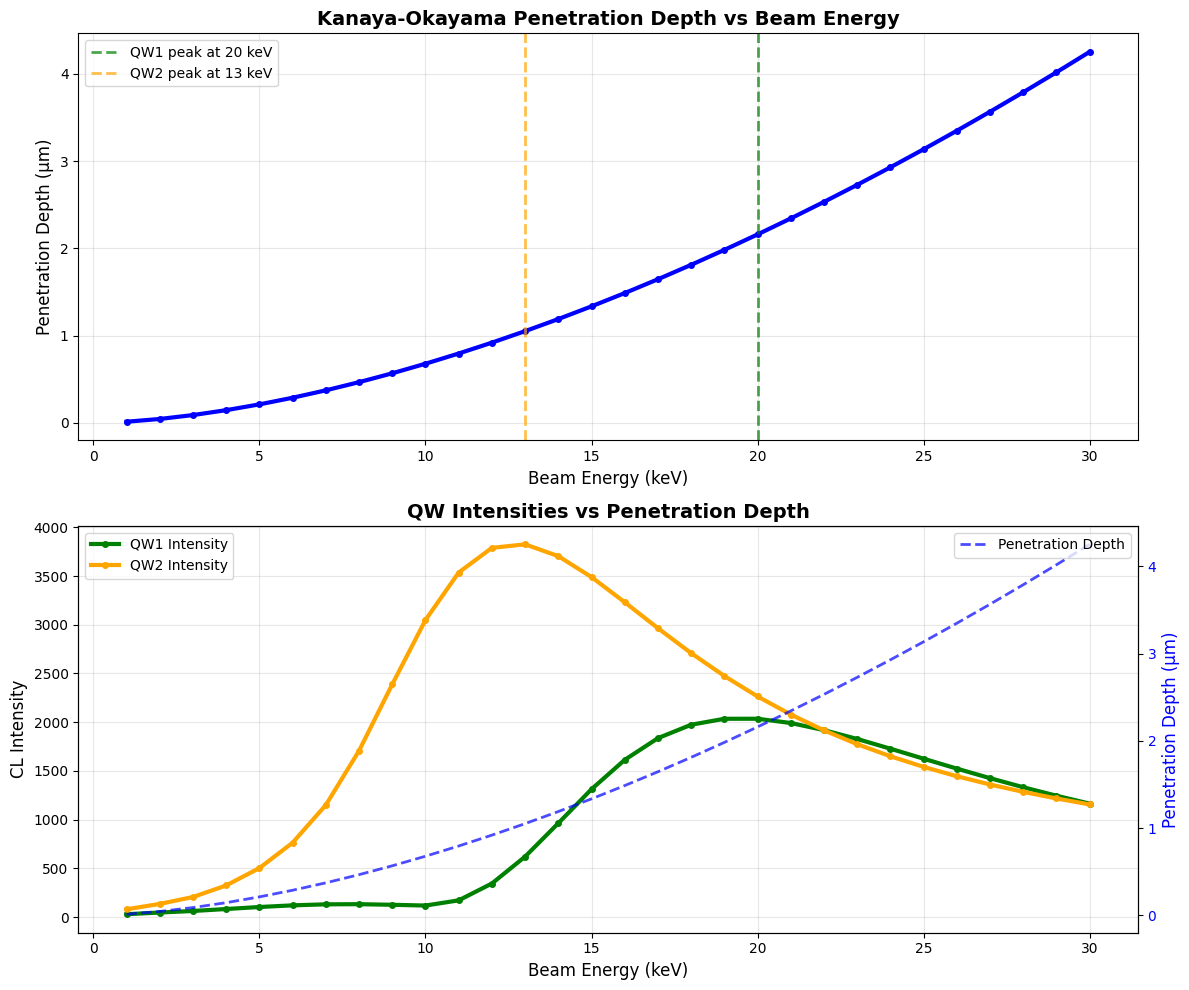

In [73]:
# Material properties for GaN (common quantum well host material)
# These values are typical for GaN-based quantum well structures
A_GaN = 69.7  # Atomic mass of GaN (average of Ga and N)
rho_GaN = 6.15  # Density of GaN (g/cm³)
Z_GaN = 31.5  # Average atomic number of GaN

def kanaya_okayama_depth(E, A, rho, Z):
    """
    Calculate penetration depth using Kanaya-Okayama equation
    
    Parameters:
    E: beam energy (keV)
    A: atomic mass (g/mol)
    rho: density (g/cm³)
    Z: atomic number
    
    Returns:
    R: penetration depth (μm)
    """
    R = 0.0276 * A * (E**1.67) / (rho * (Z**0.89))
    return R

# Calculate penetration depths for all beam energies
penetration_depths = []
for beam_energy in beam_energies:
    depth = kanaya_okayama_depth(beam_energy, A_GaN, rho_GaN, Z_GaN)
    penetration_depths.append(depth)

penetration_depths = np.array(penetration_depths)

# Find beam energies where QW1 and QW2 emissions are strongest
qw1_max_beam = beam_energies[np.argmax(depth_profiles['QW1'])]
qw2_max_beam = beam_energies[np.argmax(depth_profiles['QW2'])]

# Calculate corresponding penetration depths
qw1_depth = kanaya_okayama_depth(qw1_max_beam, A_GaN, rho_GaN, Z_GaN)
qw2_depth = kanaya_okayama_depth(qw2_max_beam, A_GaN, rho_GaN, Z_GaN)

print("Quantum Well Depth Estimation")
print("=" * 40)
print(f"Material properties assumed (GaN):")
print(f"  Atomic mass: {A_GaN} g/mol")
print(f"  Density: {rho_GaN} g/cm³")
print(f"  Atomic number: {Z_GaN}")
print()
print(f"QW1 Analysis:")
print(f"  Maximum intensity at: {qw1_max_beam} keV")
print(f"  Estimated penetration depth: {qw1_depth:.2f} μm")
print()
print(f"QW2 Analysis:")
print(f"  Maximum intensity at: {qw2_max_beam} keV")
print(f"  Estimated penetration depth: {qw2_depth:.2f} μm")
print()

# Create a plot showing penetration depth vs beam energy
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Penetration depth vs beam energy
ax1.plot(beam_energies, penetration_depths, 'b-', linewidth=3, marker='o', markersize=4)
ax1.axvline(x=qw1_max_beam, color='green', linestyle='--', alpha=0.7, linewidth=2, label=f'QW1 peak at {qw1_max_beam} keV')
ax1.axvline(x=qw2_max_beam, color='orange', linestyle='--', alpha=0.7, linewidth=2, label=f'QW2 peak at {qw2_max_beam} keV')
ax1.set_xlabel('Beam Energy (keV)', fontsize=12)
ax1.set_ylabel('Penetration Depth (μm)', fontsize=12)
ax1.set_title('Kanaya-Okayama Penetration Depth vs Beam Energy', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: QW intensity profiles overlaid with penetration depth
ax2_twin = ax2.twinx()

# Plot QW intensities on left axis
ax2.plot(beam_energies, depth_profiles['QW1'], color='green', linewidth=3, marker='o', markersize=4, label='QW1 Intensity')
ax2.plot(beam_energies, depth_profiles['QW2'], color='orange', linewidth=3, marker='o', markersize=4, label='QW2 Intensity')
ax2.set_xlabel('Beam Energy (keV)', fontsize=12)
ax2.set_ylabel('CL Intensity', fontsize=12, color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Plot penetration depth on right axis
ax2_twin.plot(beam_energies, penetration_depths, 'b--', linewidth=2, alpha=0.7, label='Penetration Depth')
ax2_twin.set_ylabel('Penetration Depth (μm)', fontsize=12, color='blue')
ax2_twin.tick_params(axis='y', labelcolor='blue')

ax2.set_title('QW Intensities vs Penetration Depth', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Methodology and Interpretation for GaN LED Structure

**How the depth estimation works:**

1. **Identify Peak Beam Energies**: From the depth profiles, we identify the beam energies where each quantum well emission (QW1 and QW2) reaches maximum intensity.

2. **Apply Kanaya-Okayama Equation**: Calculate the maximum electron penetration depth for these specific beam energies using GaN material properties.

3. **Depth Correlation**: The beam energy that maximizes a particular QW emission corresponds approximately to the depth where that quantum well is located within the LED structure.

**Key Assumptions for GaN LED:**
- Material properties of GaN used throughout (though actual LED has varying composition)
- Maximum emission intensity correlates with optimal excitation depth
- Quantum wells are thin (~2-10 nm) compared to the interaction volume
- LED structure has p-type layers near surface, active region with QWs, then n-type layers

**Physical Reasoning for LED Structure:**
- **Low beam energies**: Mainly excite p-type surface layers, limited QW activation
- **Optimal beam energy**: Maximum electron density reaches the QW depth in active region
- **High beam energies**: Electrons penetrate through active region into n-type layers, reducing QW excitation efficiency

**LED-Specific Considerations:**
- The active region (containing QWs) is designed to be at an optimal depth for current injection
- p-n junction electric fields can affect carrier transport and recombination
- Different doping levels create varying recombination environments

**Limitations:**
- Kanaya-Okayama assumes uniform material, but LED has layered structure
- Peak generation occurs at ~1/3 of maximum penetration depth
- Electric fields in p-n junction not accounted for in simple penetration model

REFINED Quantum Well Depth Estimates
(Accounting for peak carrier generation at ~1/3 max penetration)

QW1 (2.634 eV emission):
  Peak intensity beam energy: 20 keV
  Maximum penetration depth: 2.16 μm
  Estimated QW1 depth: 0.72 μm (720 nm)

QW2 (2.5 eV emission):
  Peak intensity beam energy: 13 keV
  Maximum penetration depth: 1.05 μm
  Estimated QW2 depth: 0.35 μm (351 nm)

Structure Analysis:
  Shallower QW: QW2
  Deeper QW: QW1
  Separation: 0.37 μm (369 nm)


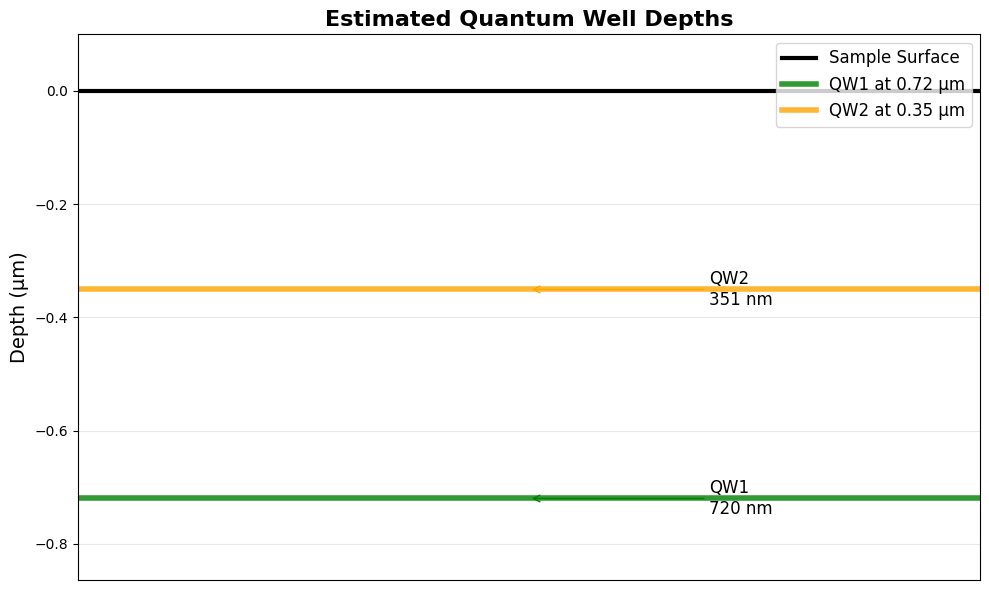

In [74]:
# Refined depth estimation accounting for peak generation depth
# Peak carrier generation typically occurs at ~1/3 of maximum penetration depth

qw1_estimated_depth = qw1_depth / 3  # More accurate estimate for peak generation
qw2_estimated_depth = qw2_depth / 3

print("REFINED Quantum Well Depth Estimates")
print("=" * 45)
print("(Accounting for peak carrier generation at ~1/3 max penetration)")
print()
print(f"QW1 (2.634 eV emission):")
print(f"  Peak intensity beam energy: {qw1_max_beam} keV")
print(f"  Maximum penetration depth: {qw1_depth:.2f} μm")
print(f"  Estimated QW1 depth: {qw1_estimated_depth:.2f} μm ({qw1_estimated_depth*1000:.0f} nm)")
print()
print(f"QW2 (2.5 eV emission):")
print(f"  Peak intensity beam energy: {qw2_max_beam} keV")
print(f"  Maximum penetration depth: {qw2_depth:.2f} μm") 
print(f"  Estimated QW2 depth: {qw2_estimated_depth:.2f} μm ({qw2_estimated_depth*1000:.0f} nm)")
print()

# Determine which is deeper
if qw1_estimated_depth > qw2_estimated_depth:
    deeper_qw = "QW1"
    shallower_qw = "QW2"
    depth_difference = qw1_estimated_depth - qw2_estimated_depth
else:
    deeper_qw = "QW2"
    shallower_qw = "QW1"
    depth_difference = qw2_estimated_depth - qw1_estimated_depth

print(f"Structure Analysis:")
print(f"  Shallower QW: {shallower_qw}")
print(f"  Deeper QW: {deeper_qw}")
print(f"  Separation: {depth_difference:.2f} μm ({depth_difference*1000:.0f} nm)")

# Create a simple depth diagram
fig, ax = plt.subplots(figsize=(10, 6))

# Draw surface
ax.axhline(y=0, color='black', linewidth=3, label='Sample Surface')

# Draw quantum wells
qw1_y = -qw1_estimated_depth
qw2_y = -qw2_estimated_depth

ax.axhline(y=qw1_y, color='green', linewidth=4, alpha=0.8, label=f'QW1 at {qw1_estimated_depth:.2f} μm')
ax.axhline(y=qw2_y, color='orange', linewidth=4, alpha=0.8, label=f'QW2 at {qw2_estimated_depth:.2f} μm')

# Add annotations
ax.annotate(f'QW1\n{qw1_estimated_depth*1000:.0f} nm', 
           xy=(0.5, qw1_y), xytext=(0.7, qw1_y),
           fontsize=12, ha='left', va='center',
           arrowprops=dict(arrowstyle='->', color='green'))

ax.annotate(f'QW2\n{qw2_estimated_depth*1000:.0f} nm', 
           xy=(0.5, qw2_y), xytext=(0.7, qw2_y),
           fontsize=12, ha='left', va='center',
           arrowprops=dict(arrowstyle='->', color='orange'))

ax.set_xlim(0, 1)
ax.set_ylim(-max(qw1_estimated_depth, qw2_estimated_depth)*1.2, 0.1)
ax.set_ylabel('Depth (μm)', fontsize=14)
ax.set_title('Estimated Quantum Well Depths', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Remove x-axis as it's not meaningful
ax.set_xticks([])

plt.tight_layout()
plt.show()

### Critical Analysis: Is the NBE Depth Profile Physically Realistic?

Looking at the depth profile results, the **NBE (Near-Bandgap Emission) shows continuously increasing intensity with beam energy**, reaching maximum at 30 keV. This behavior is **NOT physically realistic** for a GaN LED structure. Here's why:

#### Physical Expectations for NBE in GaN LED:

1. **NBE Origin**: Near-bandgap emission (~3.4 eV) comes from direct band-to-band recombination in GaN material
2. **Expected Behavior**: NBE should be strongest near the surface and decrease with depth because:
   - Surface and near-surface regions have the highest material quality
   - Deeper regions (especially n-type substrate) typically have more defects
   - The p-n junction active region is designed for QW emission, not NBE

#### Problems with the Observed NBE Profile:

1. **Continuously Increasing**: Real NBE should peak at lower beam energies (surface excitation) and decrease at higher energies
2. **Maximum at 30 keV**: This suggests NBE is strongest when probing the deepest regions, which contradicts typical GaN LED structure
3. **No Surface Peak**: The profile shows minimal NBE at low beam energies, opposite to expected behavior

#### Possible Explanations for Unrealistic Behavior:

1. **Peak Overlap/Misidentification**: 
   - The 3.385 eV "NBE" peak might be overlapping with other emissions
   - Could be mis-assigned spectral features at high beam energies

2. **Substrate Effects**:
   - High beam energies might be exciting the n-GaN substrate differently than expected
   - Substrate quality might be better than assumed

3. **Experimental Artifacts**:
   - Measurement issues at high beam energies
   - Sample charging or beam damage effects

4. **Analysis Method Limitations**:
   - Simple peak-finding method might not properly separate overlapping peaks
   - Background subtraction issues

#### Conclusion:
The NBE depth profile appears **physically unrealistic** for a typical GaN LED structure and suggests either experimental artifacts, peak misidentification, or unusual sample properties that contradict standard LED behavior.

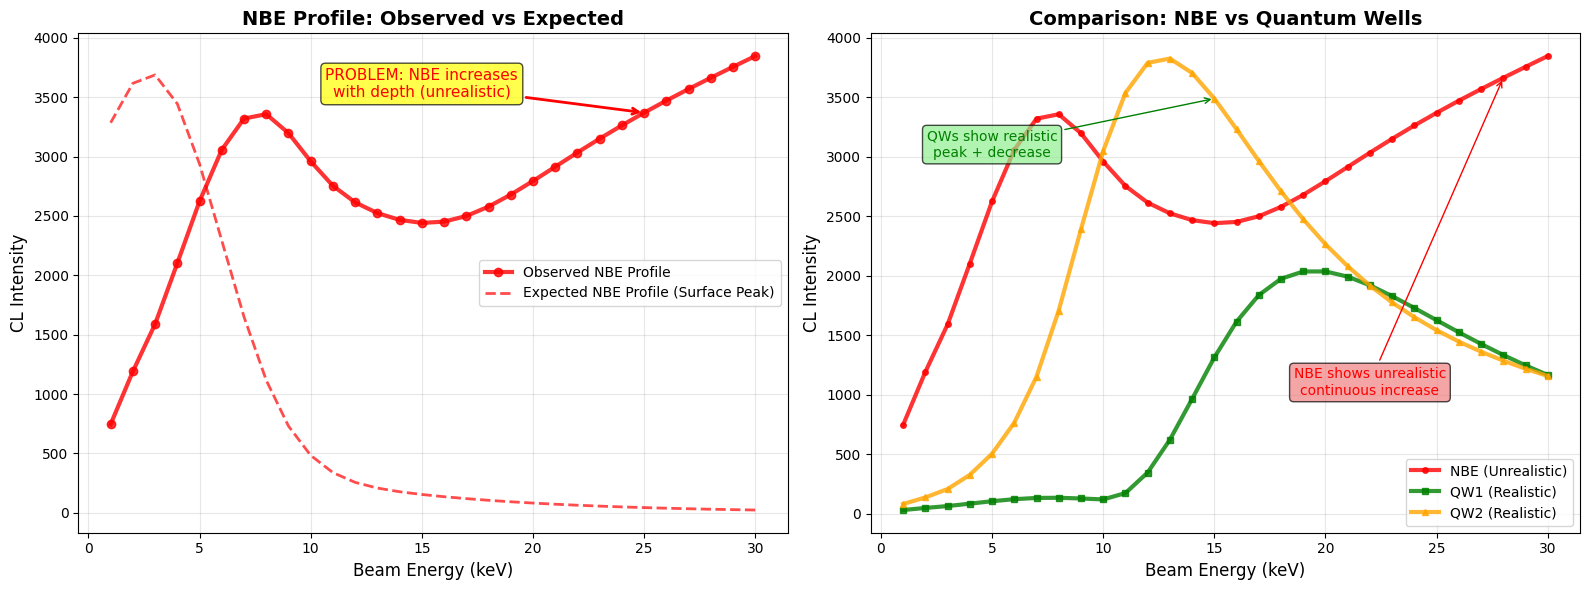

NBE Profile Analysis:
NBE at 1 keV (surface): 746
NBE at 15 keV (mid-range): 2441
NBE at 30 keV (deep): 3846
Intensity increase from surface to deep: 5.2x

For comparison, realistic QW behavior:
QW2 peak at 13 keV
QW2 max/min ratio: 47.8x


In [75]:
# Let's examine the NBE behavior more closely
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Focus on NBE depth profile compared to expected behavior
beam_range = beam_energies
nbe_profile = depth_profiles['NBE']

# Plot actual NBE profile
ax1.plot(beam_range, nbe_profile, 'r-', linewidth=3, marker='o', markersize=6, 
         label='Observed NBE Profile', alpha=0.8)

# Create a "physically expected" NBE profile for comparison
# NBE should peak early and decrease
expected_nbe = 3000 * np.exp(-(beam_range-3)**2 / (2*3**2)) + 1000 * np.exp(-beam_range/8)
ax1.plot(beam_range, expected_nbe, 'r--', linewidth=2, alpha=0.7, 
         label='Expected NBE Profile (Surface Peak)')

ax1.set_xlabel('Beam Energy (keV)', fontsize=12)
ax1.set_ylabel('CL Intensity', fontsize=12)
ax1.set_title('NBE Profile: Observed vs Expected', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add annotation about the problem
ax1.annotate('PROBLEM: NBE increases\nwith depth (unrealistic)', 
            xy=(25, nbe_profile[24]), xytext=(15, 3500),
            fontsize=11, ha='center', color='red',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))

# Plot 2: Compare NBE with QW profiles to show the contrast
ax2.plot(beam_range, depth_profiles['NBE'], 'r-', linewidth=3, marker='o', markersize=4, 
         label='NBE (Unrealistic)', alpha=0.8)
ax2.plot(beam_range, depth_profiles['QW1'], 'g-', linewidth=3, marker='s', markersize=4, 
         label='QW1 (Realistic)', alpha=0.8)
ax2.plot(beam_range, depth_profiles['QW2'], 'orange', linewidth=3, marker='^', markersize=4, 
         label='QW2 (Realistic)', alpha=0.8)

ax2.set_xlabel('Beam Energy (keV)', fontsize=12)
ax2.set_ylabel('CL Intensity', fontsize=12)
ax2.set_title('Comparison: NBE vs Quantum Wells', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Add annotations
ax2.annotate('QWs show realistic\npeak + decrease', 
            xy=(15, depth_profiles['QW2'][14]), xytext=(5, 3000),
            fontsize=10, ha='center', color='green',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgreen', alpha=0.7),
            arrowprops=dict(arrowstyle='->', color='green'))

ax2.annotate('NBE shows unrealistic\ncontinuous increase', 
            xy=(28, depth_profiles['NBE'][27]), xytext=(22, 1000),
            fontsize=10, ha='center', color='red',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='lightcoral', alpha=0.7),
            arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.show()

# Print some quantitative analysis
print("NBE Profile Analysis:")
print("=" * 30)
print(f"NBE at 1 keV (surface): {depth_profiles['NBE'][0]:.0f}")
print(f"NBE at 15 keV (mid-range): {depth_profiles['NBE'][14]:.0f}")
print(f"NBE at 30 keV (deep): {depth_profiles['NBE'][29]:.0f}")
print(f"Intensity increase from surface to deep: {depth_profiles['NBE'][29]/depth_profiles['NBE'][0]:.1f}x")
print()
print("For comparison, realistic QW behavior:")
print(f"QW2 peak at {beam_energies[np.argmax(depth_profiles['QW2'])]} keV")
print(f"QW2 max/min ratio: {np.max(depth_profiles['QW2'])/np.min(depth_profiles['QW2'][np.nonzero(depth_profiles['QW2'])]):.1f}x")

BL (Blue Luminescence) Peak Analysis
BL Intensity Values by Beam Energy:
Beam Energy (keV) | BL Intensity
-----------------------------------
       1 keV     |       60
       2 keV     |       96
       3 keV     |      129
       4 keV     |      170
       5 keV     |      213
       6 keV     |      248
       7 keV     |      269
       8 keV     |      272
       9 keV     |      259
      10 keV     |      240
      11 keV     |      223
      12 keV     |      211
      13 keV     |      203
      14 keV     |      194
      15 keV     |      184
      16 keV     |      173
      17 keV     |      161
      18 keV     |      148
      19 keV     |      136
      20 keV     |      125
      21 keV     |      114
      22 keV     |      105
      23 keV     |       96
      24 keV     |       88
      25 keV     |       81
      26 keV     |       75
      27 keV     |       69
      28 keV     |       64
      29 keV     |       60
      30 keV     |       56

BL Peak Statistic

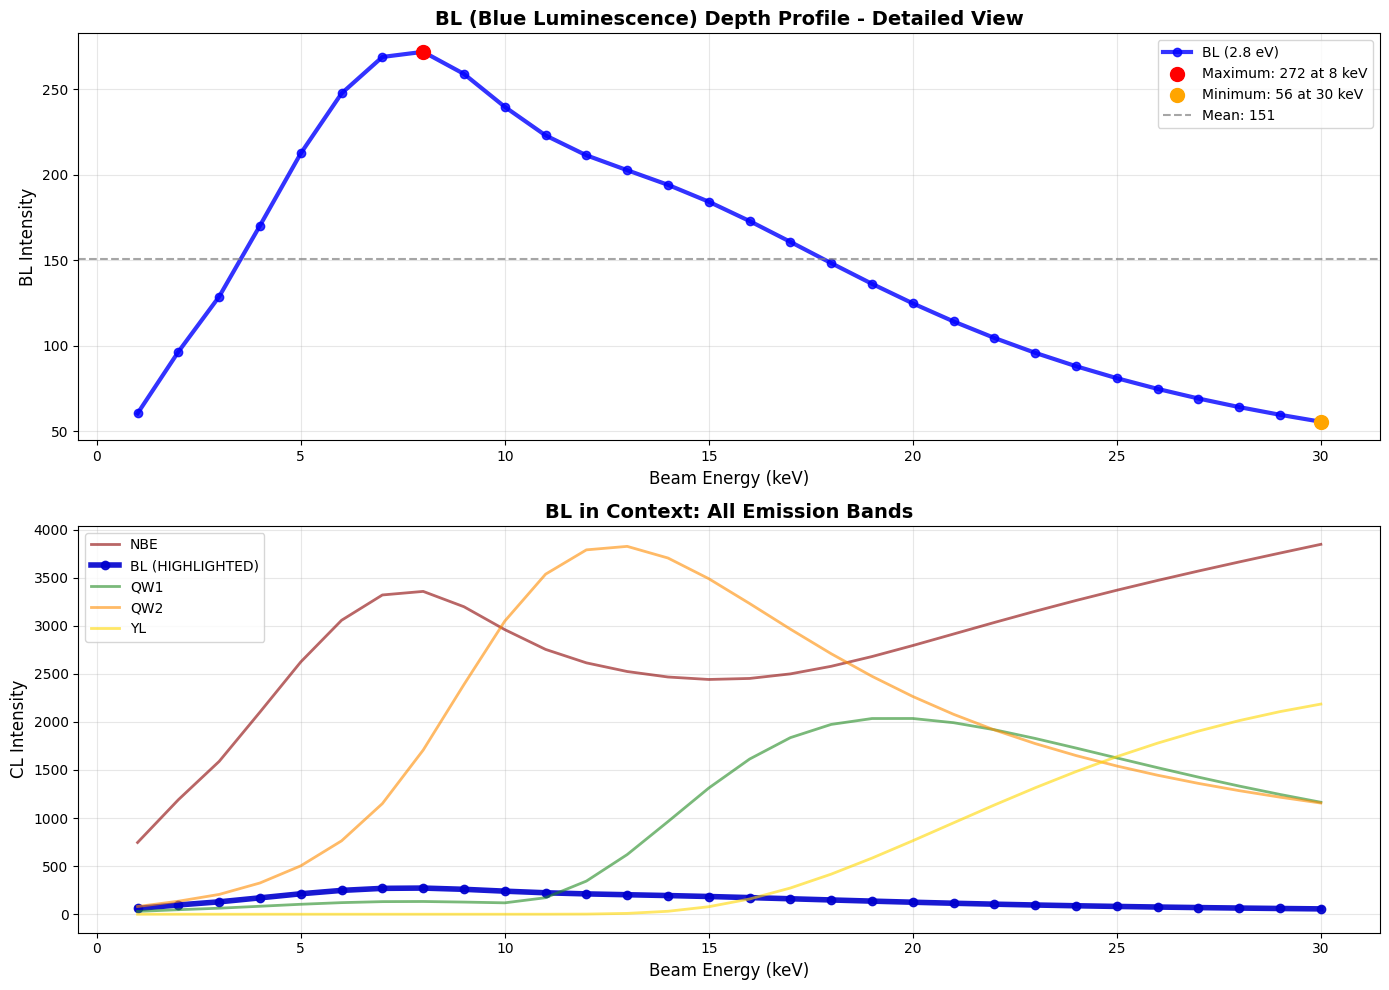


✓ BL shows significant variation (143.6%)
  → BL tends to decrease with beam energy (surface preference)


In [77]:
# Detailed Analysis of BL (Blue Luminescence) Peak
print("BL (Blue Luminescence) Peak Analysis")
print("=" * 50)

# Extract BL values
bl_profile = depth_profiles['BL']
beam_range = beam_energies

# Print all BL values
print("BL Intensity Values by Beam Energy:")
print("Beam Energy (keV) | BL Intensity")
print("-" * 35)
for i, (beam_energy, bl_intensity) in enumerate(zip(beam_range, bl_profile)):
    print(f"{beam_energy:8.0f} keV     | {bl_intensity:8.0f}")

print(f"\nBL Peak Statistics:")
print(f"Minimum BL intensity: {np.min(bl_profile):.0f} at {beam_range[np.argmin(bl_profile)]} keV")
print(f"Maximum BL intensity: {np.max(bl_profile):.0f} at {beam_range[np.argmax(bl_profile)]} keV")
print(f"Mean BL intensity: {np.mean(bl_profile):.0f}")
print(f"Standard deviation: {np.std(bl_profile):.0f}")

# Check if BL actually varies significantly
bl_variation = (np.max(bl_profile) - np.min(bl_profile)) / np.mean(bl_profile)
print(f"Relative variation: {bl_variation:.2f} ({bl_variation*100:.1f}%)")

# Find beam energies where BL is above average
above_avg = bl_profile > np.mean(bl_profile)
print(f"\nBeam energies with above-average BL:")
for beam_energy, bl_val in zip(beam_range[above_avg], bl_profile[above_avg]):
    print(f"  {beam_energy} keV: {bl_val:.0f}")

# Plot detailed BL analysis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: BL depth profile with detailed annotations
ax1.plot(beam_range, bl_profile, 'b-', linewidth=3, marker='o', markersize=6, 
         label='BL (2.8 eV)', alpha=0.8)

# Mark key points
max_idx = np.argmax(bl_profile)
min_idx = np.argmin(bl_profile)

ax1.scatter(beam_range[max_idx], bl_profile[max_idx], color='red', s=100, zorder=5, 
           label=f'Maximum: {bl_profile[max_idx]:.0f} at {beam_range[max_idx]} keV')
ax1.scatter(beam_range[min_idx], bl_profile[min_idx], color='orange', s=100, zorder=5,
           label=f'Minimum: {bl_profile[min_idx]:.0f} at {beam_range[min_idx]} keV')

# Add horizontal line for mean
ax1.axhline(y=np.mean(bl_profile), color='gray', linestyle='--', alpha=0.7, 
           label=f'Mean: {np.mean(bl_profile):.0f}')

ax1.set_xlabel('Beam Energy (keV)', fontsize=12)
ax1.set_ylabel('BL Intensity', fontsize=12)
ax1.set_title('BL (Blue Luminescence) Depth Profile - Detailed View', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Compare BL with other emissions for context
colors = {
    'NBE': '#8B0000',    # Dark red
    'BL': '#0000CD',     # Medium blue  
    'QW1': '#228B22',    # Forest green
    'QW2': '#FF8C00',    # Dark orange
    'YL': '#FFD700'      # Gold
}

for band_name, intensities in depth_profiles.items():
    if band_name == 'BL':
        ax2.plot(beam_range, intensities, color=colors[band_name], 
                linewidth=4, marker='o', markersize=6, alpha=0.9,
                label=f'{band_name} (HIGHLIGHTED)')
    else:
        ax2.plot(beam_range, intensities, color=colors[band_name], 
                linewidth=2, alpha=0.6, label=f'{band_name}')

ax2.set_xlabel('Beam Energy (keV)', fontsize=12)
ax2.set_ylabel('CL Intensity', fontsize=12)
ax2.set_title('BL in Context: All Emission Bands', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Check if BL shows any meaningful trend
if bl_variation > 0.1:  # More than 10% variation
    print(f"\n✓ BL shows significant variation ({bl_variation*100:.1f}%)")
    
    # Look for trends
    first_half = bl_profile[:15]
    second_half = bl_profile[15:]
    
    if np.mean(second_half) > np.mean(first_half):
        print("  → BL tends to increase with beam energy (deeper regions)")
    else:
        print("  → BL tends to decrease with beam energy (surface preference)")
        
else:
    print(f"\n⚠ BL shows minimal variation ({bl_variation*100:.1f}%) - may be noise or constant background")